# K-Means Clustering — Customer Segmentation

**Dataset:** Mall Customers (Kaggle)
https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

**Goal:** Group customers into segments based on Age, Income, and Spending Score — without any labels (unsupervised learning).

## Workflow

1. Load & explore the dataset
2. Encode categorical features
3. Select features
4. Scale the data
5. Find optimal K using the Elbow Method
6. Train the final model
7. Visualize clusters

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans

## Step 2: Load & Explore the Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
print("Missing Values:", df.isnull().sum())

Missing Values: CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## Step 3: Encode Categorical Features

`Gender` is text — we convert it to 0/1 using `LabelEncoder` so the model can work with it.

In [8]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [9]:
df['Gender'].value_counts()

Gender
0    112
1     88
Name: count, dtype: int64

In [10]:
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


## Step 4: Select Features

We drop `CustomerID` (just an index) and use the remaining 4 columns as input features.

In [11]:
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [12]:
X

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


## Step 5: Scale the Features

K-Means uses distance, so features with larger ranges will dominate. Scaling puts all features on the same playing field.

> We try both `StandardScaler` and `MinMaxScaler` — final model uses MinMaxScaler.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_scaled

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [15]:
mm_scaler = MinMaxScaler()
X_scaled = mm_scaler.fit_transform(X)

In [16]:
X_scaled[0:5] # Standard scaling

array([[1.        , 0.01923077, 0.        , 0.3877551 ],
       [1.        , 0.05769231, 0.        , 0.81632653],
       [0.        , 0.03846154, 0.00819672, 0.05102041],
       [0.        , 0.09615385, 0.00819672, 0.7755102 ],
       [0.        , 0.25      , 0.01639344, 0.39795918]])

In [17]:
X_scaled[0:5]

array([[1.        , 0.01923077, 0.        , 0.3877551 ],
       [1.        , 0.05769231, 0.        , 0.81632653],
       [0.        , 0.03846154, 0.00819672, 0.05102041],
       [0.        , 0.09615385, 0.00819672, 0.7755102 ],
       [0.        , 0.25      , 0.01639344, 0.39795918]])

## Step 6: Find Optimal K — Elbow Method

We run K-Means for K = 1 to 29, recording the **WCSS** (Within-Cluster Sum of Squares) each time.
The "elbow" in the plot — where the curve bends — is the optimal K.

In [18]:
wcss = []
K_range = range(1, 30)

In [19]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=20, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # Inertia = WCSS

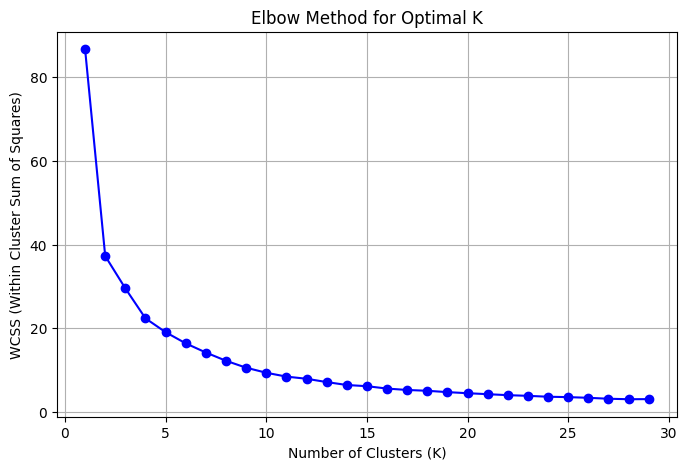

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, 'bo-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [21]:
k_optimal = 4

## Step 7: Train Final Model with K = 4

In [22]:
kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', random_state=20, n_init=10)

In [23]:
kmeans_final.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=20)

### Cluster Centroids

After fitting, K-Means has found the **center point of each cluster**. Let's look at them in the original scale so they're readable.

In [24]:
centroids = pd.DataFrame(
    mm_scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=X.columns
)
centroids.index.name = 'Cluster'
centroids

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,-2.775558e-16,48.109091,58.818182,34.781818
1,1.000000e+00,28.250000,62.000000,71.675000
2,1.000000e+00,49.437500,62.416667,29.208333
3,-3.330669e-16,28.438596,59.666667,67.684211


### What do these cluster numbers mean?

**Nothing by themselves.** K-Means just labels groups as 0, 1, 2, 3 — the numbers have no built-in meaning.

You interpret each cluster by looking at its centroid values:

| Question to ask | Column to look at |
|---|---|
| Young or old? | `Age` |
| Rich or not? | `Annual Income (k$)` |
| Do they spend? | `Spending Score (1-100)` |

**Example interpretation:**
- High income + High spending score → "Premium Customers"
- High income + Low spending score → "Careful Spenders"
- Low income + High spending score → "Impulsive Buyers"
- Low income + Low spending score → "Budget Customers"

> This is the analyst's job — the model finds the groups, you give them names.

In [25]:
df['Cluster'] = kmeans_final.predict(X_scaled)

In [26]:
df.head(15)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,1
1,2,1,21,15,81,1
2,3,0,20,16,6,0
3,4,0,23,16,77,3
4,5,0,31,17,40,3
5,6,0,22,17,76,3
6,7,0,35,18,6,0
7,8,0,23,18,94,3
8,9,1,64,19,3,2
9,10,0,30,19,72,3


## Step 8: Visualize Clusters

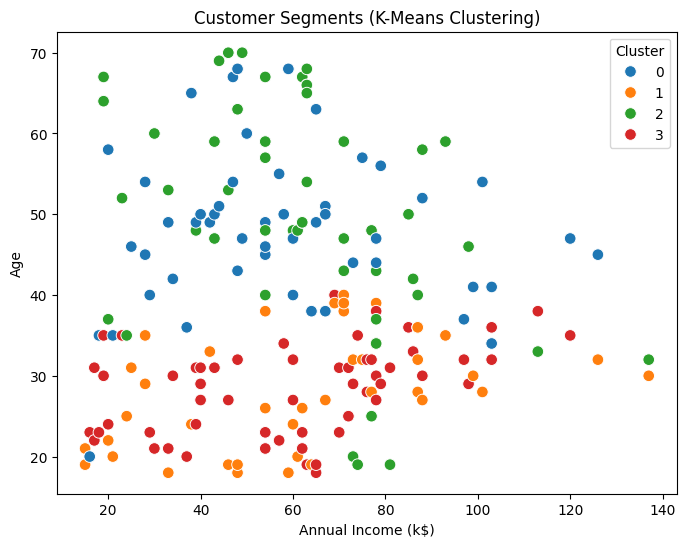

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Annual Income (k$)', y='Age',
    hue='Cluster', palette='tab10', data=df, s=70
)
plt.title('Customer Segments (K-Means Clustering)')
plt.show()

In [28]:
from sklearn.decomposition import PCA

## Step 9: PCA — Compress to 2D for Better Visualization

With 4 features we can't plot everything at once. PCA reduces them to 2 components so we can see all clusters in a single 2D scatter plot.

In [29]:
# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [30]:
X_pca

array([[ 0.53295542, -0.22784075],
       [ 0.51393907, -0.49307991],
       [-0.44626589,  0.08707859],
       [-0.47879569, -0.36661673],
       [-0.45198432,  0.00300619],
       [-0.47905919, -0.37382159],
       [-0.43069765,  0.29588454],
       [-0.48682386, -0.48573543],
       [ 0.59720084,  0.65030769],
       [-0.46852807, -0.23475757],
       [ 0.59471063,  0.61538677],
       [-0.47701748, -0.35344875],
       [-0.41158991,  0.55348602],
       [-0.47682392, -0.35359718],
       [ 0.56528242,  0.20358955],
       [ 0.51715368, -0.46633419],
       [-0.44449221,  0.09277798],
       [ 0.52189242, -0.40373564],
       [ 0.57308163,  0.30048935],
       [-0.47555073, -0.34740109],
       [ 0.55322264,  0.0212041 ],
       [ 0.52414077, -0.38353428],
       [-0.41744385,  0.45469933],
       [ 0.53041637, -0.3000585 ],
       [-0.41317979,  0.50279592],
       [ 0.52462364, -0.39147651],
       [-0.43124278,  0.25160046],
       [ 0.54117158, -0.16119671],
       [-0.43552899,

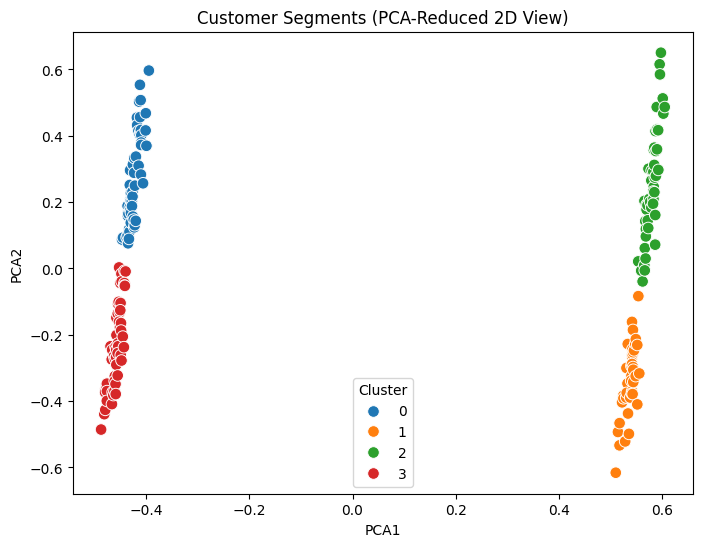

In [31]:
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Plot clusters in PCA space
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='tab10', data=df, s=70)
plt.title('Customer Segments (PCA-Reduced 2D View)')
plt.show()

## Summary

- K-Means grouped 200 customers into **4 segments** based on Age, Income, and Spending patterns.
- No labels were needed — purely unsupervised.
- The Elbow Method helped us pick K = 4 objectively.
- PCA gave us a clean 2D view of the clusters.

---

### Take-home exercise 

Find an interesting dataset for **clustering** on Kaggle. Apply K-Means clustering, find the optimal K using the Elbow Method, and interpret your clusters.

> **Important:** pick a dataset with **no target/label column**. Clustering is unsupervised — if the data already has the answer in it, you are not really clustering.

Write your solution as a Jupyter notebook with explanation and visualizations.

Explain the dataset you chose and which columns you used as features.
How many rows does your dataset have? Why is clustering a good fit for this data?

YOUR ANSWER HERE

Write all your code below. Make sure to include:
- Elbow plot to justify your choice of K
- Cluster visualization (scatter plot or PCA plot)
- Centroid table in original scale
- Your interpretation of each cluster (what does each group represent?)

In [32]:
# Your code here

---

## Solution

**Dataset:** Unsupervised Learning on Country Data
https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

**Why this dataset?** It has **no target/label column** — just socio-economic indicators for 167 countries. That's exactly what clustering is for: there is no "correct answer" to compare against, so the groupings must come from the data itself.

**Features:** `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, `gdpp`

**Rows:** 167 countries

**Goal:** Group countries by development level to help decide which ones need aid.

In [33]:
df_c = pd.read_csv("Country-data.csv")
df_c.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [34]:
print("Shape:", df_c.shape)
print("\nMissing values:\n", df_c.isnull().sum())
df_c.describe()

Shape: (167, 10)

Missing values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


### Select Features & Scale

`country` is just a name (like `CustomerID` earlier) — we drop it. The remaining 9 columns are all numeric, so no encoding is needed.

Scaling matters a lot here: `gdpp` is in the tens of thousands while `total_fer` is around 2. Without scaling, GDP would completely dominate the distance calculation.

In [35]:
X_c = df_c.drop('country', axis=1)

scaler_c = MinMaxScaler()
X_c_scaled = scaler_c.fit_transform(X_c)

X_c.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Elbow Method

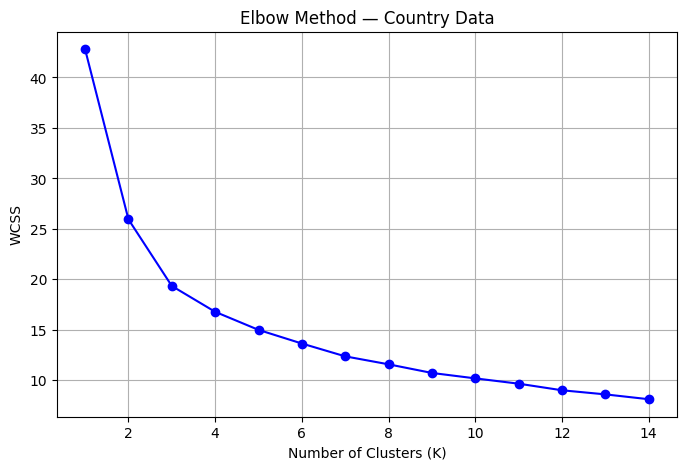

In [36]:
wcss_c = []
K_range_c = range(1, 15)

for k in K_range_c:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_c_scaled)
    wcss_c.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range_c, wcss_c, 'bo-')
plt.title('Elbow Method — Country Data')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

The curve bends around **K = 3** — after that the WCSS drops only slightly. We'll use K = 3.

> Note: we have no labels to check this against. The elbow plot is our only evidence — which is the normal situation in real clustering problems.

### Train Final Model

In [37]:
km_c = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
km_c.fit(X_c_scaled)

df_c['Cluster'] = km_c.predict(X_c_scaled)
df_c['Cluster'].value_counts()

Cluster
2    87
1    46
0    34
Name: count, dtype: int64

### Centroid Table (Original Scale)

In [38]:
centroids_c = pd.DataFrame(
    scaler_c.inverse_transform(km_c.cluster_centers_),
    columns=X_c.columns
)
centroids_c.index.name = 'Cluster'
centroids_c[['child_mort', 'income', 'life_expec', 'gdpp']].round(1)

,child_mort,income,life_expec,gdpp
Cluster,,,,
0,4.8,46408.8,80.4,43897.1
1,93.3,3516.8,59.4,1695.9
2,22.2,12913.7,72.6,6833.4


### Cluster Visualization (PCA)

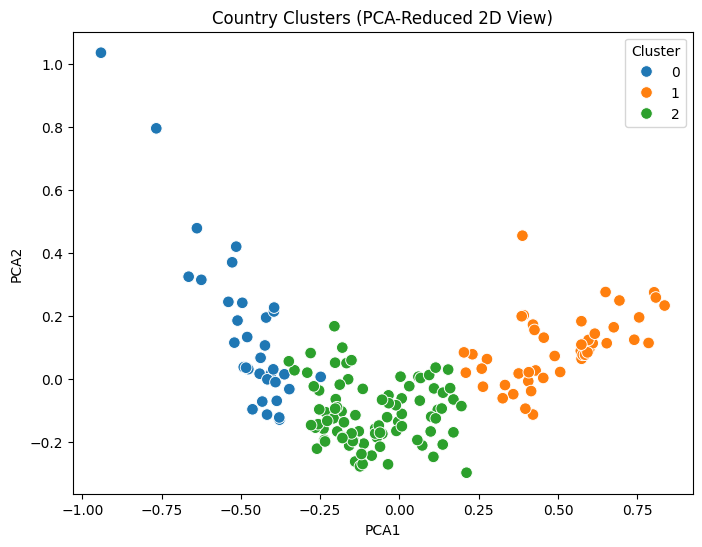

In [39]:
pca_c = PCA(n_components=2)
X_c_pca = pca_c.fit_transform(X_c_scaled)

df_c['PCA1'] = X_c_pca[:, 0]
df_c['PCA2'] = X_c_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='tab10', data=df_c, s=70)
plt.title('Country Clusters (PCA-Reduced 2D View)')
plt.show()

### Cluster Interpretation

Let's look at a few countries from each cluster to sanity-check our reading of the centroids.

In [40]:
for c in sorted(df_c['Cluster'].unique()):
    sample = df_c[df_c['Cluster'] == c]['country'].head(8).tolist()
    print(f"Cluster {c} ({(df_c['Cluster'] == c).sum()} countries): {sample}\n")

Cluster 0 (34 countries): ['Australia', 'Austria', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark']

Cluster 1 (46 countries): ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad']

Cluster 2 (87 countries): ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bahrain']

